# Modeling the spread of infectious disease with compartimental models

Let us start exploring how infectious diseases spread using the simplest mathematical framework: compartmental models. <br>
We will begin with the basic models and progressively introduce additional mechanisms. Along the way, we will define a few helper functions to simulate disease outbreaks under different epidemiological assumptions. <br>
For the sake of simplicity let us consider measles as the disease we want to model:
|           | $R_0$ | Infectious period | $ \gamma $  | $ \beta $|
| ---------------- | --------------: | ----------------: | --------------: | -------------: |
| measles     |              15 |            9 days |            0.11 |       **1.67** |




In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

### 0 - Before starting: the Euler method

The compartmental models are described by a system of ordinary differential equations (ODEs).

In general, if

$$
\frac{dx}{dt} = f(x,t),
$$

the Euler method approximates the solution by taking small discrete steps in time:

$$
x_{t+\Delta t} \approx x_t + \Delta t\, f(x_t,t).
$$

In words:

> **new value = current value + time step × rate of change**

The smaller the time step $\Delta t$, the better the approximation usually becomes.

### 1 - The SIR model

One of the simplest but most relevant models is based on the idea that the population consists of three groups:

  - **S(t)** Susceptible (those who have not yet been infected)
  - **I(t)** Infected (those who can currently spread the disease)
  - **R(t)** Recovered (those who are now immune and cannot contract or spread the disease)


$$ S \to I \to R$$



\begin{align}
\frac{dS}{dt} & = -\beta I \frac{S}{N} \\
\frac{dI}{dt} & = \beta I \frac{S}{N}-\gamma I \\
\frac{dR}{dt} & = \gamma I
\end{align}

Remembering that $\beta$ is the number of others that one infected person encounters per unit time, and $\gamma^{-1}$ as the typical time from infection to recovery, the number of new infections generated by one infected individual is, on average, the **basic reproduction number**: $$\beta/\gamma = R_0,$$

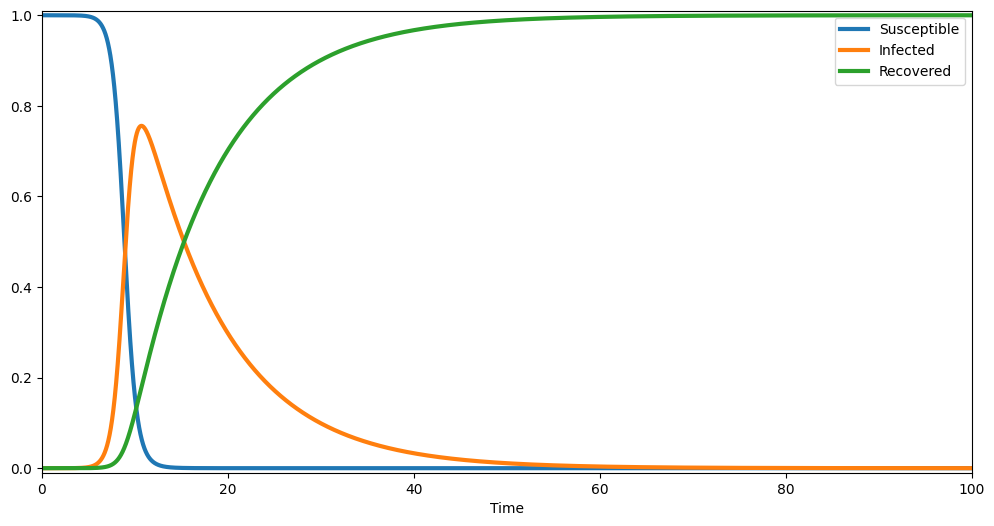

In [ ]:
beta = 1.67
gamma = 0.11
N = 1.

# Initial values

R = [0]
I = [1e-6]
S = [N - I[0] - R[0]]

def change(S,I,R):
    S_change = -beta*I*S/N
    I_change = beta*I*S/N - gamma*I
    R_change = gamma*I
    return S_change, I_change, R_change


T = 100
dt = 0.01
times = np.linspace(0,T,int(T/dt)+1)

for t in times[1:]:
    S_change, I_change, R_change = change(S[-1],I[-1],R[-1])
    I.append(I[-1]+dt*I_change)
    S.append(S[-1]+dt*S_change)
    R.append(R[-1]+dt*R_change)

plt.figure(figsize=(12,6))
plt.plot(times,S,lw=3);
plt.plot(times,I,lw=3);
plt.plot(times,R,lw=3);
plt.legend(['Susceptible','Infected','Recovered'])
plt.xlabel('Time');
plt.xlim(0,100); plt.ylim(-.01,1.01);

Here I've set $N=1$ so the numbers on the vertical axis represent a fraction of the current population.  Initially, only a tiny fraction is infected while the remainder is susceptible.  The plot above shows the typical behavior of an epidemic: an initial rapid exponential spread, until much of the population is infected or recovered, at which point the number of infections begins to decline.



### 2 - The SI model

In the **SI model**, infected individuals do not recover: they remain infectious. The population has only two compartments, susceptible and infected.

$$ S \to I $$

\begin{align}
\frac{dS}{dt} &= -\beta I\frac{S}{N} \\
\frac{dI}{dt} &= \beta I\frac{S}{N}
\end{align}

With no recovery, the infected fraction keeps increasing until almost everyone is infected.

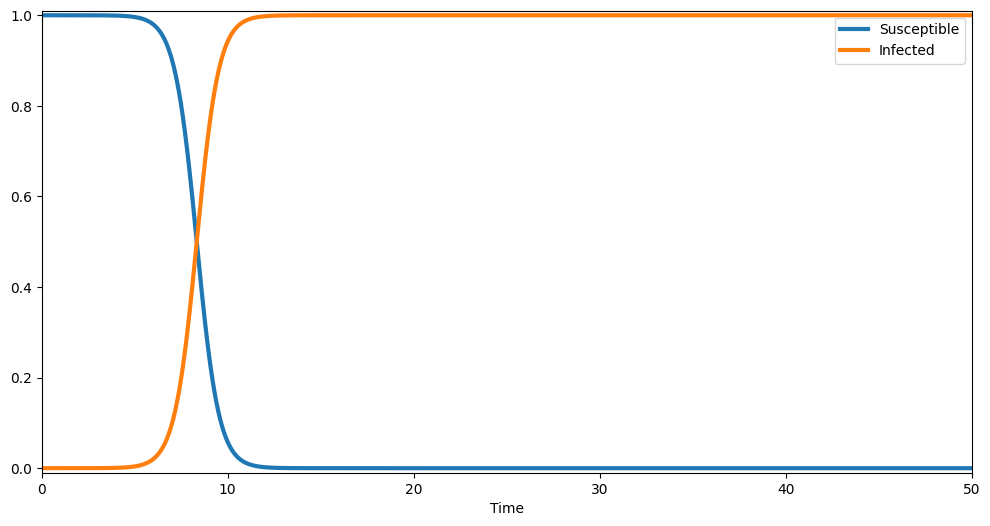

In [17]:
beta = 1.67
gamma = 0.11
N = 1.

# Initial values

I = [1e-6]
S = [N - I[0]]

def change(S,I):
    S_change = -beta*I*S/N
    I_change = beta*I*S/N 
    return S_change, I_change


T = 50
dt = 0.01
times = np.linspace(0,T,int(T/dt)+1)

for t in times[1:]:
    S_change, I_change = change(S[-1],I[-1])
    I.append(I[-1]+dt*I_change)
    S.append(S[-1]+dt*S_change)

plt.figure(figsize=(12,6))
plt.plot(times,S,lw=3);
plt.plot(times,I,lw=3);
plt.legend(['Susceptible','Infected'])
plt.xlabel('Time');
plt.xlim(0,50); plt.ylim(-.01,1.01);

### 3 - The SIS model

In the **SIS model**, infected individuals recover but do not acquire immunity: they become susceptible again. As in SI, there are only two compartments.

$$ S \to I \to S $$

\begin{align}
\frac{dS}{dt} &= -\beta I\frac{S}{N} + \gamma I \\
\frac{dI}{dt} &= \beta I\frac{S}{N} - \gamma I
\end{align}

When $\beta > \gamma$, infection can persist: the infected fraction approaches $1-\gamma/\beta$.

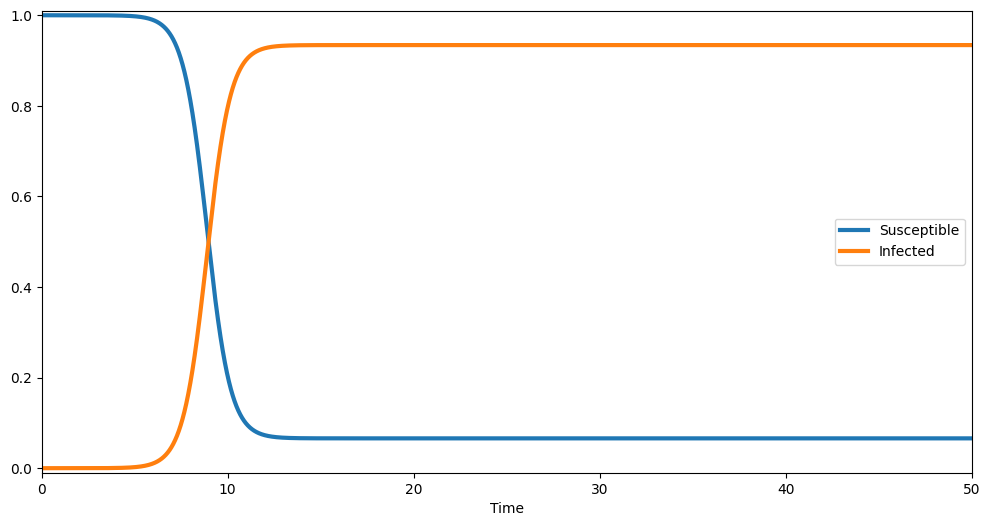

In [4]:
beta = 1.67
gamma = 0.11
N = 1.

# Initial values

I = [1e-6]
S = [N - I[0]]

def change(S,I):
    S_change = -beta*I*S/N + gamma*I
    I_change = beta*I*S/N - gamma*I
    return S_change, I_change


T = 50
dt = 0.01
times = np.linspace(0,T,int(T/dt)+1)

for t in times[1:]:
    S_change, I_change = change(S[-1],I[-1])
    I.append(I[-1]+dt*I_change)
    S.append(S[-1]+dt*S_change)

plt.figure(figsize=(12,6))
plt.plot(times,S,lw=3);
plt.plot(times,I,lw=3);
plt.legend(['Susceptible','Infected'])
plt.xlabel('Time');
plt.xlim(0,50); plt.ylim(-.01,1.01);

### 4 - Exercise: the SEIR model

Add **E(t)**, the exposed individuals: they have been infected but are not yet infectious. They become infectious at rate $\sigma$, so $1/\sigma$ is the mean latent period.

$$ S \to E \to I \to R $$

\begin{align}
\frac{dS}{dt} &= -\beta I\frac{S}{N} \\
\frac{dE}{dt} &= \beta I\frac{S}{N} - \sigma E \\
\frac{dI}{dt} &= \sigma E - \gamma I \\
\frac{dR}{dt} &= \gamma I
\end{align}

**Your turn:** simulate 100 days with $\sigma=1/3$ per day and plot all four compartments. How does the infected peak change compared with SIR?

**Hint:** copy the SIR code, add `E = [0]`, and set `S = [N - E[0] - I[0] - R[0]]`. Make `change(S,E,I,R)` return four rates, compute them from the previous values, then update each list with Euler's method. Keep the same `beta`, `gamma`, `I[0]` and `dt` for the comparison.

In [ ]:
# Complete the SEIR simulation here
sigma = 1/3
# TODO: initial values, change function, Euler loop and plot

### 5 - Exercise: the SIRV model

Add **V(t)**, the vaccinated individuals. Susceptible individuals are vaccinated at rate $\nu$. Assume vaccination gives immediate, complete and permanent protection, with no loss of natural immunity either.

$$ S \to I \to R, \qquad S \to V $$

\begin{align}
\frac{dS}{dt} &= -\beta I\frac{S}{N} - \nu S \\
\frac{dI}{dt} &= \beta I\frac{S}{N} - \gamma I \\
\frac{dR}{dt} &= \gamma I \\
\frac{dV}{dt} &= \nu S
\end{align}

**Your turn:** simulate 100 days with $\nu=0.05$ per day and plot all four compartments. Compare the infected peak with the case $\nu=0$.

**Hint:** copy the SIR code, add `V = [0]`, and subtract `V[0]` when setting the initial susceptible fraction. Make `change(S,I,R,V)` return four rates, then extend the Euler loop and legend. Vaccination removes people from `S` and adds them to `V`.

In [ ]:
# Complete the SIRV simulation here
nu = 0.05
# TODO: initial values, change function, Euler loop and plot

### 6 - Exercise: the SIRD model

Add **D(t)**, the cumulative deaths due to the disease. Infected individuals can recover at rate $\gamma$ or die at rate $\mu$; both processes remove them from the infectious compartment.

$$ S \to I \to R, \qquad I \to D $$

\begin{align}
\frac{dS}{dt} &= -\beta I\frac{S}{N} \\
\frac{dI}{dt} &= \beta I\frac{S}{N} - \gamma I - \mu I \\
\frac{dR}{dt} &= \gamma I \\
\frac{dD}{dt} &= \mu I
\end{align}

Here we use the fixed initial population $N=S+I+R+D$ in the infection term. The mean time until recovery or death is $1/(\gamma+\mu)$.

**Your turn:** simulate 100 days with $\mu=0.01$ per day and plot all four compartments. What fraction of the initial population has died by the end?

**Hint:** copy the SIR code, add `D = [0]`, and subtract `D[0]` when setting the initial susceptible fraction. Make `change(S,I,R,D)` return four rates and extend the Euler loop. Remember to subtract `mu*I` from the infected rate as well as adding it to the death rate.

For each exercise, keep $N=1$ and $\Delta t=0.01$ as above. Check that the four fractions remain non-negative and sum to 1 (up to rounding).

In [ ]:
# Complete the SIRD simulation here
mu = 0.01
# TODO: initial values, change function, Euler loop and plot